### Imports

In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [7]:

class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [8]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [9]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [10]:

graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [11]:

intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'Here\'s a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and well-structured for a general audience interested in technology and India\'s growth.\n\n---\n\n## Blog Title Options:\n\n*   **The AI Awakening: How India is Becoming a Global Powerhouse**\n*   **From Code to Consciousness: Charting India\'s Ascent in the AI Revolution**\n*   **India\'s AI Moment: Unpacking the Drivers, Impact, and Future of Artificial Intelligence**\n*   **Beyond the Hype: The Real Story of AI\'s Rise in India**\n\n---\n\n## Blog Outline: The Rise of AI in India\n\n**Target Audience:** Tech enthusiasts, business professionals, policymakers, students, and anyone interested in India\'s digital transformation and the future of AI.\n\n**Tone:** Informative, optimistic, analytical, and forward-looking, with a balanced view of opportunities and challenges.\n\n---\n\n### I. Introduction: Setting the Stage for India\

In [12]:

print(final_state['outline'])

Here's a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and well-structured for a general audience interested in technology and India's growth.

---

## Blog Title Options:

*   **The AI Awakening: How India is Becoming a Global Powerhouse**
*   **From Code to Consciousness: Charting India's Ascent in the AI Revolution**
*   **India's AI Moment: Unpacking the Drivers, Impact, and Future of Artificial Intelligence**
*   **Beyond the Hype: The Real Story of AI's Rise in India**

---

## Blog Outline: The Rise of AI in India

**Target Audience:** Tech enthusiasts, business professionals, policymakers, students, and anyone interested in India's digital transformation and the future of AI.

**Tone:** Informative, optimistic, analytical, and forward-looking, with a balanced view of opportunities and challenges.

---

### I. Introduction: Setting the Stage for India's AI Journey

*   **A. Catchy Hook:**
    *   Start with a compelling st

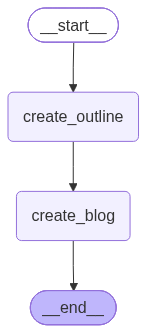

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())